In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class DifferentiablePainting(nn.Module):
    def __init__(self, image_size):
        super().__init__()
        self.image_size = image_size
        
        # Parameters to optimize: x, y, r, g, b, size of the dot
        self.dots = nn.Parameter(torch.rand(6))
        
        # Initialize x, y to be integers between 0 and image_size-1
        self.dots.data[:2] = torch.floor(self.dots.data[:2] * torch.tensor(image_size))
        # Normalize r, g, b to be between 0 and 1
        self.dots.data[2:5] /= 255.0
        # Normalize size to be between 1 and 20 pixels
        self.dots.data[5] = torch.floor(self.dots.data[5] * 19 + 1)
        # initialize empty canvas
        self.canvas = torch.ones(3, image_size[0], image_size[1])

    def forward(self):
        x, y, r, g, b, size = self.dots
        # Use a differentiable approximation of rounding for x and y
        x = self.continuous_round(x)
        y = self.continuous_round(y)
        # Ensure size is a positive integer
        size = torch.clamp(self.continuous_round(size), min=1)
        
        # Create a grid of coordinates
        yy, xx = torch.meshgrid(torch.arange(self.image_size[1], dtype=torch.float32),
                                torch.arange(self.image_size[0], dtype=torch.float32))
        
        # Calculate the distance from each pixel to the dot center
        distance = torch.sqrt((xx - x)**2 + (yy - y)**2)
        
        # Create a mask for the dot
        mask = torch.sigmoid(10 * (size/2 - distance)).unsqueeze(0)
        
        # Apply the dot to the canvas
        dot_color = torch.tensor([r, g, b]).view(3, 1, 1)
        self.canvas = self.canvas * (1 - mask) + dot_color * mask
        
        return self.canvas

    def continuous_round(self, x):
        return x - torch.sin(2 * torch.pi * x) / (2 * torch.pi)

In [4]:
# def load_image(path, size):
#     img = Image.open(path).convert('RGB')
#     transform = transforms.Compose([
#         transforms.Resize((size, size)),
#         transforms.ToTensor()
#     ])
#     return transform(img)

# def train(target_image, num_iterations):
#     model = DifferentiablePainting(image_size=target_image.shape[1:])
#     optimizer = optim.Adam(model.parameters(), lr=0.01)
#     loss_fn = nn.MSELoss()

#     for i in range(num_iterations):
#         optimizer.zero_grad()
#         output = model()
#         loss = loss_fn(output, target_image)
#         loss.backward()
#         optimizer.step()
        
#         if i % 100 == 0:
#             print(f"Iteration {i}, Loss: {loss.item()}")
    
#     return model

In [5]:
torch.rand(5, 1).repeat(1,3)

tensor([[0.5226, 0.5226, 0.5226],
        [0.9910, 0.9910, 0.9910],
        [0.0755, 0.0755, 0.0755],
        [0.8437, 0.8437, 0.8437],
        [0.1674, 0.1674, 0.1674]])

In [213]:
class SequentialPainting(nn.Module):
    def __init__(self, image_size):
        super().__init__()
        self.image_size = image_size
        # Parameters to optimize: x, y, and size for each dot
        self.dot_position = nn.Parameter(torch.rand(3), requires_grad=True)
        # color parameters to optimize: r, g, b ; now gray scale
        self.dot_color = nn.Parameter(torch.rand(1, requires_grad=True)).repeat(3)        
        # Initialize x, y to be between 0 and image_size-1
        self.dot_position.data[:2] = self.dot_position.data[:2] * torch.tensor(self.image_size)
        # Initialize size to be between 1 and 20 pixels
        self.dot_position.data[2] = self.dot_position.data[2] * 19 + 1        
        # Initialize canvas
        #self.register_buffer('canvas', torch.ones(3, image_size[0], image_size[1]))

    def forward(self, canvas):
        # Create a fresh computational graph for the canvas
        #canvas = self.canvas.clone()
        
        x, y, size = self.dot_position
        r, g, b = self.dot_color
        
        # Use a differentiable approximation of rounding for x and y
        x = self.continuous_round(x)
        y = self.continuous_round(y)
        # Ensure size is a positive value
        size = torch.clamp(size, min=1)
        
        # Create a grid of coordinates
        yy, xx = torch.meshgrid(torch.arange(self.image_size[1], dtype=torch.float32),
                                torch.arange(self.image_size[0], dtype=torch.float32))
        
        # Calculate the distance from each pixel to the dot center
        distance = torch.sqrt((xx - x)**2 + (yy - y)**2)
        
        # Create a mask for the dot
        mask = torch.sigmoid(10 * (size/2 - distance)).unsqueeze(0)
        
        # Apply the dot to the canvas
        dot_color = torch.tensor([r, g, b]).view(3, 1, 1)
        canvas_new = (canvas * (1 - mask) + dot_color * mask)
        
        return canvas_new

    def update_canvas(self, new_canvas):
        # TEST SEQUENTIAL ADDING OF DOTS WHEN CALLING FORWARD MULTIPLE TIMES...
        # ARE DOTS ADDES SEQUENTIALLY OR ONLY LAST DOT IS SAVED ON CANVAS ?
        self.canvas = new_canvas.detach()  # Detach to separate from computational graph

    def continuous_round(self, x):
        return x - torch.sin(2 * torch.pi * x) / (2 * torch.pi)

def load_and_preprocess_image(image_path, image_size):
    image = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor()
    ])
    return transform(image).unsqueeze(0)

def train(model, target_image, num_iterations=1000, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()
    canvas = torch.ones(3, target_image.shape[2], target_image.shape[3])

    
    for i in range(num_iterations):
        optimizer.zero_grad()
        canvas = model(canvas)
        loss = mse_loss(canvas, target_image[0])
        loss.backward(retain_graph=True)
        optimizer.step()
        
        # Update the canvas state
        #model.update_canvas(output)
        if (i+1) % 100 == 0:
            print(f'Iteration {i+1}/{num_iterations}, Loss: {loss.item():.4f}')
    
    return model


In [214]:
image_size = (256, 256)  # Height, Width
# Usage
target_image = load_and_preprocess_image('../benchmark/img/flower.jpg', image_size=image_size)


In [215]:
model = SequentialPainting(image_size)
result = train(model, target_image, num_iterations=1000)

RuntimeError: Output 2 of UnbindBackward0 is a view and its base or another view of its base has been modified inplace. This view is the output of a function that returns multiple views. Such functions do not allow the output views to be modified inplace. You should replace the inplace operation by an out-of-place one.

In [191]:
model.canvas.max()

tensor(1.)

Text(0.5, 1.0, 'Generated Image')

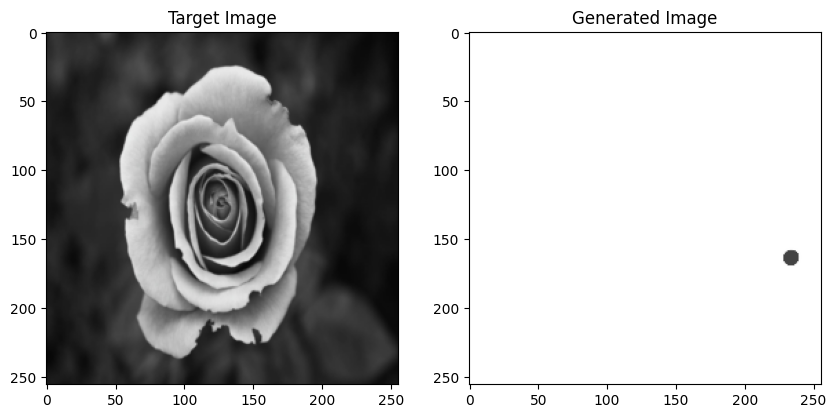

In [192]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(target_image[0].permute(1, 2, 0))
plt.title('Target Image')
plt.subplot(1, 2, 2)
plt.imshow(result.canvas.detach().permute(1, 2, 0))
plt.title('Generated Image')

In [15]:
result.canvas

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])

In [66]:
diff_painting = DifferentiablePainting(image_size=target_image.shape[1:3])

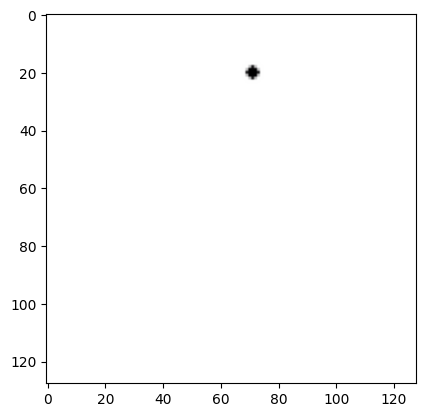

In [72]:
plt.imshow(diff_painting.canvas.detach().swapaxes(0,2))

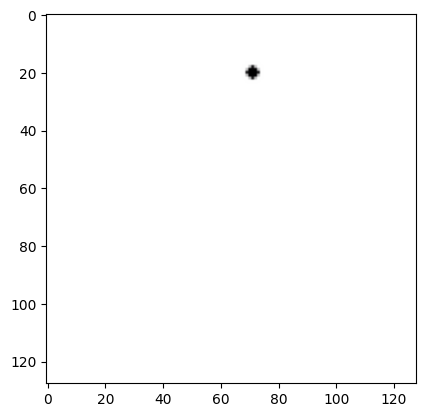

In [71]:
plt.imshow(diff_painting.forward().detach().swapaxes(0,2))

In [38]:
target_image.shape

torch.Size([3, 128, 128])

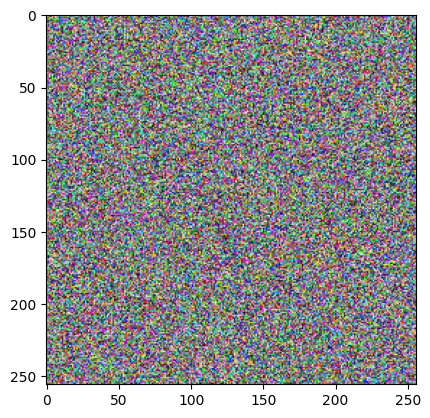

In [64]:
a = torch.rand(256, 256, 3)
plt.imshow(a)

(array([19617., 19760., 19758., 19829., 19570., 19483., 19716., 19787.,
        19638., 19450.]),
 array([1.43051147e-06, 1.00000791e-01, 2.00000152e-01, 2.99999505e-01,
        3.99998873e-01, 4.99998242e-01, 5.99997580e-01, 6.99996948e-01,
        7.99996316e-01, 8.99995685e-01, 9.99995053e-01]),
 <BarContainer object of 10 artists>)

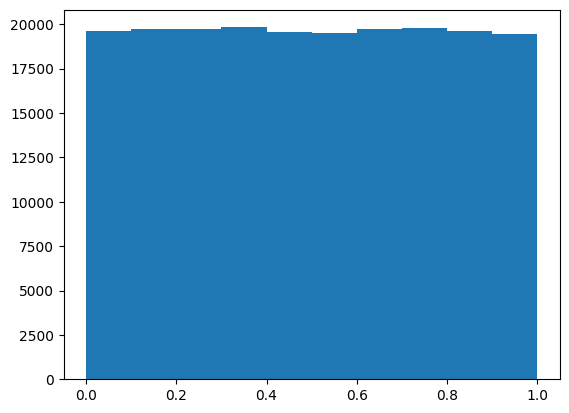

In [65]:
plt.hist(a.flatten())